## Cos'è un Normalizing Flow?

Un Normalizing Flow impara a **trasformare la distribuzione complessa dei dati p(x)
in una distribuzione semplice e nota** — una gaussiana standard N(0, I) — tramite una
sequenza di trasformazioni **invertibili e differenziabili** f.

```
x  ──f──▶  z = f(x) ~ N(0, I)
z ◀──f⁻¹── x            (la trasformazione si può invertire)
```

La chiave è la formula del **change of variables**: se z = f(x) è invertibile,

```
log p(x) = log p_z(f(x)) + log |det J_f(x)|
```

dove J_f è lo Jacobiano di f. Il primo termine dice "quanto è centrale z nella
gaussiana"; il secondo corregge per come f comprime o dilata il volume localmente.

A differenza del VAE — che la likelihood la tocca solo con un *lower bound* (l'ELBO) —
il flow calcola **log p(x) in modo ESATTO**. È il suo punto di forza, ed è il motivo
per cui il suo anomaly score è la likelihood stessa.

## Come si addestra

Massimizzando la log-likelihood dei dati QCD, cioè **minimizzando la NLL**
(Negative Log-Likelihood). Il flow impara a mappare i jet QCD verso il centro della
gaussiana, dove la densità è alta.

## Perché funziona per l'anomaly detection

> Addestriamo **solo su QCD**. Un jet QCD viene mappato dove la densità è alta
> → `log p(x)` alta. Un Emerging Jet, fuori distribuzione, finisce dove la densità
> è bassa → `log p(x)` bassa.

L'anomaly score è quindi:

```
score = − log p(x)        (più alto = più anomalo)
```

| Tipo di jet | log p(x) | score = −log p(x) |
|---|---|---|
| QCD (background) | alta | **basso** |
| Emerging Jet (segnale) | bassa | **alto** |

## Cosa ci aspettiamo

Stesso input del VAE (43 feature **aggregate**) → AUC dello stesso ordine (~0.76):
l'informazione di partenza è la stessa. Il valore di questo step è **metodologico** —
un **tipo di anomaly score diverso (likelihood esatta)** che, insieme al reconstruction
error di AE/VAE, copre il quadro richiesto dalla consegna (reconstruction error /
likelihood / flow score).

------------------------------------------------------------------------------------------------------------------------------------------

NOTA: usiamo solo **aggregate** perché il tuning degli "input encodings" è stato già
fatto col Flat AE (aggregate vs pt_sorted vs d0_sorted), e aggregate vinceva nettamente.
Non ci aspettiamo differenze perché la scelta dell'encoding è una proprietà della
**rappresentazione dei dati**, non del modello: aggregate vince per invarianza per
permutazione e compattezza — un argomento **agnostico al modello**, quindi valido
uguale per AE, VAE e NF (tutti modelli su vettore flat). Il risultato del tuning fatto
sul modello più semplice (AE) si trasferisce. L'unico encoding *strutturalmente* diverso
(il set non ordinato di tracce) richiede un modello track-level (GNN/Transformer) → step
successivo, non una manopola da attaccare a un modello flat.

SCHEMA — score naturale per famiglia di modelli:
- modelli a ricostruzione (AE, VAE)   → reconstruction error  (MSE: "riesco a ricostruirlo?")
- modelli di densità (Normalizing Flow) → likelihood / flow score  (−log p(x) ESATTA: "quanto è probabile?")
- modelli a diffusione                → errore di denoising / bound sulla likelihood

NOTE chiave:
- "likelihood" e "flow score" sono la STESSA famiglia: il flow score è semplicemente la
  likelihood, ma calcolata in modo ESATTO dal flow. Il VAE invece la tocca solo come
  *lower bound* (l'ELBO), non esatta → per questo come score del VAE usiamo l'MSE.
- GNN e Transformer NON sono una famiglia di score: sono **architetture** (track-level).
  Adottano uno degli score sopra a seconda di come li costruisci (es. in versione
  autoencoder → reconstruction error).
- In sostanza due domande di fondo: "riesco a ricostruirlo?" (ricostruzione) vs
  "quanto è probabile sotto il QCD che ho imparato?" (densità/likelihood).

# 04 — Normalizing Flow (RealNVP) per Anomaly Detection
### Emerging Jets vs QCD

In questo notebook costruiamo un **Normalizing Flow** (RealNVP) per riconoscere jet anomali.
L'idea di fondo è semplice: insegniamo al modello *com'è fatto* un jet QCD ordinario, e poi
segnaliamo come anomalo qualunque jet che il modello giudica "improbabile".

**Cos'è un normalizing flow, intuitivamente.**
È una trasformazione **invertibile** che impara a "raddrizzare" i dati: prende la distribuzione
complicata dei jet e la deforma, passo dopo passo, finché non assomiglia a una semplice gaussiana
N(0, I) — una palla sferica centrata nell'origine. Poiché la trasformazione è invertibile e ne
sappiamo calcolare lo Jacobiano, possiamo risalire alla **densità di probabilità esatta** p(x) di
ogni jet. È questo che distingue un flow da un autoencoder: non misura un errore di ricostruzione,
ti dice direttamente *quanto è probabile* un jet.

**Perché funziona per l'anomaly detection.**
Alleniamo il flow **solo su jet QCD**. Un Emerging Jet ha una struttura diversa, quindi cade in
una regione che il modello ha imparato essere rara → p(x) piccola → −log p(x) grande. Usiamo perciò:

$$\text{anomaly score} = -\log p(x) \qquad (\text{più alto} = \text{più anomalo})$$

**Come procediamo.** Carichiamo e prepariamo i dati, li portiamo in una forma adatta al flow,
definiamo e alleniamo il RealNVP sul solo QCD, e infine misuriamo quanto bene separa gli Emerging
Jets dal fondo (distribuzione degli score, ROC, AUC, SIC) e ne tuniamo gli iperparametri.


---
## 1. Setup e iperparametri

> **In breve.** Carichiamo gli strumenti e fissiamo le impostazioni. Da tenere a mente: questo modello non comprime i dati, la sua «potenza» si regola con quanti strati impila e quanto sono grandi le reti interne.

Importiamo le librerie, fissiamo i percorsi e definiamo gli iperparametri.

Un'osservazione utile fin da subito: un normalizing flow **non ha una "dimensione latente"**.
A differenza di un autoencoder non comprime i dati in un collo di bottiglia — essendo una
trasformazione invertibile, conserva sempre la stessa dimensione (qui 43 → 43). La sua
**capacità** (quanto è flessibile) si regola con due manopole: la **profondità** `N_LAYERS`
(quanti strati di trasformazione si impilano) e la **larghezza** `HIDDEN_UNITS` (quanto sono
grandi le reti interne di ogni strato).


In [18]:
# ── Librerie ──────────────────────────────────────────────────────────────────
import os, sys, math, warnings
warnings.filterwarnings('ignore')
import numpy as np
%matplotlib inline
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

# ── Utility del progetto (stesso preprocessing usato da AE/VAE) ───────────────
PROJECT_DIR = r'C:\Users\dfraj\OneDrive\Desktop\Master\Adv_ML\Progetto\ej_anomaly'
sys.path.insert(0, PROJECT_DIR)
from Utils_NEW import (
    load_tracks, clean_tracks, zscore_normalise,
    make_aggregate_embeddings,
    compute_roc, plot_roc,
)

# ── Path dati (locali) ────────────────────────────────────────────────────────
BKG_FILE = r'C:\Users\dfraj\Downloads\pp_output_test_background.h5'
SIG_FILE = r'C:\Users\dfraj\Downloads\pp_output_test_signal.h5'
MODELS_DIR = os.path.join(PROJECT_DIR, 'models')
PLOTS_DIR  = os.path.join(PROJECT_DIR, 'plots')
os.makedirs(MODELS_DIR, exist_ok=True)
os.makedirs(PLOTS_DIR,  exist_ok=True)

# ── Device + riproducibilità ──────────────────────────────────────────────────
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
SEED = 42
torch.manual_seed(SEED); np.random.seed(SEED)
print(f'Device: {DEVICE}')

# ── Iperparametri ─────────────────────────────────────────────────────────────
N_BKG_TRAIN   = 50_000        # jet QCD usati (riduci se la RAM non basta)
REPR          = 'aggregate'   # stesso encoding di AE/VAE, per confrontare i modelli

# Capacità del flow (non c'è "latent dim": la capacità è profondità + larghezza)
N_LAYERS      = 10            # numero di coupling block (profondità del flow)
HIDDEN_UNITS  = 256          # larghezza delle reti interne s, t

# Ottimizzazione
LEARNING_RATE = 1e-3
WEIGHT_DECAY  = 1e-5         # regolarizzazione L2 (la "regularisation" del tuning)
BATCH_SIZE    = 4096
N_EPOCHS      = 100
PATIENCE      = 15
GRAD_CLIP     = 5.0          # tetto alla norma del gradiente (training più stabile)

# Split 70 / 15 / 15
TRAIN_FRAC, VAL_FRAC, TEST_FRAC = 0.70, 0.15, 0.15
SAVE_PATH = os.path.join(MODELS_DIR, f'nf_locale_L{N_LAYERS}_h{HIDDEN_UNITS}.pt')
print(f'Setup OK -> RealNVP {N_LAYERS} layer, hidden {HIDDEN_UNITS}')


Device: cpu
Setup OK -> RealNVP 10 layer, hidden 256


---
## 2. Dati e preprocessing

> **In breve.** Trasformiamo ogni jet (che ha un numero variabile di tracce) in un'unica «scheda» di 43 numeri che lo riassume, dopo aver ripulito e messo in scala i dati. È il formato che daremo in pasto al modello.

Prepariamo i dati in quattro passi (gli stessi che si userebbero per l'autoencoder o il VAE, così
i modelli restano confrontabili sullo stesso input):

1. **`load_tracks`** — carica le tracce grezze di ogni jet (fino a 200 tracce, 14 feature ciascuna)
   insieme a una maschera che distingue le tracce vere dal padding.
2. **`clean_tracks`** — sostituisce eventuali NaN/Inf con la media della feature (pulizia minima).
3. **`zscore_normalise`** — normalizza ogni feature (sottrae la media, divide per la deviazione
   standard) e applica un **clip di sicurezza a 10σ**. Il clip è volutamente largo: serve solo a
   tagliare gli artefatti numerici estremi e lascia intatta la fisica vera degli Emerging Jets, le
   cui tracce displaced restano comodamente entro i 10σ.
4. **`make_aggregate_embeddings`** — riassume ogni jet in un **vettore di lunghezza fissa (43)**:
   per ciascuna delle 14 feature calcola media, massimo e deviazione standard sulle tracce, e
   aggiunge il logaritmo del numero di tracce. In totale 14×3 + 1 = 43 numeri per jet.

**Perché riassumere in 43 numeri?** Ogni jet ha un numero *variabile* di tracce, ma un RealNVP
richiede un input di **dimensione fissa**. Comprimere il jet in 43 statistiche risolve il problema
e conserva comunque le informazioni chiave: il valore tipico (media), le code (massimo) e la
dispersione (deviazione standard) di ogni grandezza.


In [19]:
print('Caricamento background (QCD)...')
tracks_bkg = load_tracks(BKG_FILE, n_max=N_BKG_TRAIN)
mask_bkg   = tracks_bkg['valid'].astype(bool)

print('Caricamento segnale (Emerging Jets)...')
tracks_sig = load_tracks(SIG_FILE)
mask_sig   = tracks_sig['valid'].astype(bool)

X_bkg_clean, mask_bkg = clean_tracks(tracks_bkg, mask_bkg)
X_sig_clean, mask_sig = clean_tracks(tracks_sig, mask_sig)

# z-score per traccia + clip a 10 sigma (taglia solo gli artefatti numerici, non la fisica EJ)
X_bkg_norm = zscore_normalise(X_bkg_clean, mask_bkg)
X_sig_norm = zscore_normalise(X_sig_clean, mask_sig)

# riassunto del jet: da (N, 200, 14) a lunghezza variabile -> (N, 43) fisso
X_bkg = make_aggregate_embeddings(X_bkg_norm, mask_bkg)
X_sig = make_aggregate_embeddings(X_sig_norm, mask_sig)
INPUT_DIM = X_bkg.shape[1]
print(f'X_bkg: {X_bkg.shape}  X_sig: {X_sig.shape}  INPUT_DIM={INPUT_DIM}')


Caricamento background (QCD)...
Caricamento segnale (Emerging Jets)...
X_bkg: (50000, 43)  X_sig: (61966, 43)  INPUT_DIM=43


---
## 3. Standardizzazione e split dei dati

> **In breve.** Dividiamo i jet QCD in tre gruppi (allenamento, controllo, test) e portiamo tutti i 43 numeri sulla stessa scala. Serve perché il modello impara meglio, ed è più stabile, se i valori non sono troppo grandi o troppo diversi tra loro.

Dividiamo i jet QCD in train / validation / test (70 / 15 / 15) e **standardizziamo l'embedding**,
cioè riportiamo ogni colonna ad avere media 0 e deviazione standard 1.

**Perché lo facciamo.** Il flow è costruito attorno a una gaussiana standard N(0, I): impara
meglio, ed è numericamente stabile, quando le feature in ingresso hanno già all'incirca media 0 e
deviazione standard 1. Le 43 statistiche aggregate, invece, vivono su scale molto diverse fra loro
(per esempio i "massimi" arrivano fino a circa 10, mentre il logaritmo del numero di tracce sta
intorno a 4). Se le passassimo così come sono, il flow per assorbire queste differenze di scala
dovrebbe applicare fattori di trasformazione molto grandi, e l'esponenziale al loro interno
potrebbe crescere a dismisura fino a generare valori non finiti. **Per evitare questo problema**
standardizziamo: in questo modo il flow parte da dati già "ben dimensionati" e lavora in sicurezza.

Calcoliamo media e deviazione standard **solo sul training** e usiamo quegli stessi valori per
trasformare validation, test e segnale. È un punto metodologico importante: calcolare la
normalizzazione anche sui dati di test significherebbe far entrare informazione del test nel
preprocessing (data leakage), falsando la valutazione.


In [20]:
# ── Split QCD 70 / 15 / 15 ───────────────────────────────────────────────────
rng  = np.random.default_rng(SEED)
perm = rng.permutation(len(X_bkg))
n_tr = int(len(X_bkg) * TRAIN_FRAC)
n_vl = int(len(X_bkg) * VAL_FRAC)
idx_train, idx_val, idx_test = perm[:n_tr], perm[n_tr:n_tr+n_vl], perm[n_tr+n_vl:]

X_bkg_train = X_bkg[idx_train]
X_bkg_val   = X_bkg[idx_val]
X_bkg_test  = X_bkg[idx_test]

# ── Standardizzazione: media/std calcolate SOLO sul train (niente leakage) ────
agg_mean = X_bkg_train.mean(axis=0, keepdims=True)
agg_std  = X_bkg_train.std(axis=0,  keepdims=True)
agg_std[agg_std < 1e-6] = 1.0          # pavimento sulla std: evita la divisione per zero

def standardise(A):
    return ((A - agg_mean) / agg_std).astype(np.float32)

X_bkg_train_n = standardise(X_bkg_train)
X_bkg_val_n   = standardise(X_bkg_val)
X_bkg_test_n  = standardise(X_bkg_test)
X_sig_n       = standardise(X_sig)      # al segnale applichiamo la STESSA trasformazione del train

np.savez(os.path.join(MODELS_DIR, 'nf_locale_norm.npz'), mean=agg_mean, std=agg_std)

# ── DataLoader: il flow si allena solo su QCD ────────────────────────────────
train_loader = DataLoader(TensorDataset(torch.from_numpy(X_bkg_train_n)),
                          batch_size=BATCH_SIZE, shuffle=True, drop_last=True)
val_loader   = DataLoader(TensorDataset(torch.from_numpy(X_bkg_val_n)),
                          batch_size=BATCH_SIZE * 4)
n_val = len(X_bkg_val_n)

print(f'TRAIN {len(X_bkg_train_n):,} | VAL {n_val:,} | TEST {len(X_bkg_test_n):,} | SIG {len(X_sig_n):,}')
print(f'Dopo standardizzazione -> train mean~{X_bkg_train_n.mean():+.2e}, std~{X_bkg_train_n.std():.3f}')


TRAIN 35,000 | VAL 7,500 | TEST 7,500 | SIG 61,966
Dopo standardizzazione -> train mean~-1.90e-05, std~1.000


---
## 4. Il modello: RealNVP

Costruiamo il flow passo per passo, così si vede bene cosa fa. Un RealNVP è fatto di tanti
**strati** uguali, impilati uno sopra l'altro. Ogni strato segue un'idea semplice:

- prende il vettore che descrive il jet e lo **divide in due metà**;
- **tiene ferma una metà** e la usa per decidere come **ritoccare l'altra metà** (la sposta e la
  riscala un po');
- impilando molti strati, questi piccoli ritocchi si sommano e trasformano via via i dati in
  qualcosa di semplice e regolare (una gaussiana). Da questa trasformazione il modello ricava la
  probabilità di ogni jet.

**Perché rimescoliamo l'ordine delle dimensioni.**
C'è un dettaglio importante: in ogni strato una metà resta "ferma" e l'altra viene "ritoccata". Se
l'ordine non cambiasse mai, le stesse caratteristiche del jet starebbero sempre dalla parte ferma e
altre sempre dalla parte ritoccata — alcune verrebbero imparate molto peggio di altre. Per evitarlo,
**prima di ogni strato rimescoliamo l'ordine delle 43 caratteristiche**: così, strato dopo strato,
ognuna fa a turno entrambi i ruoli e tutte finiscono per "parlarsi". Il risultato è un modello che
descrive meglio i dati. Rimescolare è solo un cambio d'ordine e non altera i conti della
probabilità: serve unicamente a far lavorare meglio gli strati insieme.

**Due accorgimenti per non avere problemi numerici:**
- la parte che decide *di quanto* riscalare passa per una **`Tanh`**, che la tiene entro limiti
  ragionevoli: in questo modo i numeri non possono "esplodere" durante l'allenamento;
- usiamo l'attivazione **`SiLU`**, più morbida di una ReLU, che rende l'allenamento più stabile.

Da ricordare: il flow **non comprime i dati** — entra ed esce con 43 numeri. La sua "potenza"
dipende solo da quanti strati impiliamo e da quanto sono grandi le reti interne di ogni strato.


In [21]:
class RealNVP(nn.Module):
    '''RealNVP: pila di coupling layer affini, con una permutazione delle dimensioni
       prima di ogni layer (i passaggi sono descritti nel testo sopra).'''
    def __init__(self, dim, n_layers=10, hidden=256):
        super().__init__()
        self.dim = dim
        self.d1  = dim // 2                  # quante dim fanno da "condizione"
        d2 = dim - self.d1                   # quante dim vengono trasformate
        self.s_nets = nn.ModuleList()
        self.t_nets = nn.ModuleList()
        perms = []
        for _ in range(n_layers):
            # rete di SCALA: ultimo layer Tanh -> output in (-1,1) -> exp(s) limitato (stabile)
            self.s_nets.append(nn.Sequential(
                nn.Linear(self.d1, hidden), nn.SiLU(),
                nn.Linear(hidden, hidden), nn.SiLU(),
                nn.Linear(hidden, d2), nn.Tanh()))
            # rete di TRASLAZIONE: nessun vincolo sull'output
            self.t_nets.append(nn.Sequential(
                nn.Linear(self.d1, hidden), nn.SiLU(),
                nn.Linear(hidden, hidden), nn.SiLU(),
                nn.Linear(hidden, d2)))
            perms.append(torch.randperm(dim))            # una permutazione fissa per layer
        # le permutazioni sono buffer: fisse e salvate/caricate insieme al modello
        self.register_buffer('perms', torch.stack(perms))

    def _encode(self, x):
        '''Trasforma i dati x in z (gaussiano) e accumula il log-determinante.'''
        log_det = x.new_zeros(x.size(0))
        z = x
        for i in range(len(self.s_nets)):
            z = z[:, self.perms[i]]                       # permuta le dim (det=1: non tocca il log_det)
            z1, z2 = z[:, :self.d1], z[:, self.d1:]
            s = self.s_nets[i](z1); t = self.t_nets[i](z1)   # condiziona su z1, trasforma z2
            z2 = z2 * torch.exp(s) + t
            log_det = log_det + s.sum(1)
            z = torch.cat([z1, z2], dim=1)
        return z, log_det

    def log_prob(self, x):
        '''Densita' esatta log p(x) via cambio di variabile.'''
        z, log_det = self._encode(x)
        log_pz = -0.5 * (z ** 2 + math.log(2 * math.pi)).sum(1)   # log N(z; 0, I)
        return log_pz + log_det


def build_realnvp(dim, n_layers, hidden):
    return RealNVP(dim, n_layers, hidden)

model = build_realnvp(INPUT_DIM, N_LAYERS, HIDDEN_UNITS).to(DEVICE)
n_params = sum(p.numel() for p in model.parameters())
print(f'RealNVP: {N_LAYERS} coupling layer, hidden={HIDDEN_UNITS}  ->  {n_params:,} parametri')


RealNVP: 10 coupling layer, hidden=256  ->  1,541,560 parametri


---
## 5. Addestramento (solo su QCD)

> **In breve.** Mostriamo al modello tanti jet QCD e gli chiediamo di renderli «il più normali possibile» per lui. Così impara com'è fatto un jet ordinario: tutto ciò che dopo gli sembrerà strano diventerà candidato anomalo.

Alleniamo il flow a **massimizzare la verosimiglianza** dei jet QCD, il che equivale a
**minimizzare la NLL** (negative log-likelihood), cioè `−log p(x)` mediata sul batch. In altre
parole chiediamo al modello: "rendi i jet QCD il più probabili possibile sotto la tua densità".

Alcune scelte pratiche di questa cella:
- alleniamo **solo su QCD** e teniamo il segnale completamente da parte: il modello non deve mai
  vederlo, altrimenti la valutazione non sarebbe onesta;
- usiamo la **NLL di validazione** (sempre su QCD) per l'early stopping, salvando di volta in volta
  il modello migliore;
- applichiamo un **clip della norma del gradiente** e dimezziamo automaticamente il learning rate
  quando la validation smette di migliorare: due accorgimenti che tengono il training stabile.

Non filtriamo eventuali valori NaN durante il training: se l'impostazione è corretta non devono
comparire, e se mai comparissero vogliamo accorgercene subito anziché nasconderli.


In [22]:
opt   = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)
sched = torch.optim.lr_scheduler.ReduceLROnPlateau(opt, patience=max(1, PATIENCE // 3), factor=0.5)

best_val, wait = float('inf'), 0
train_nlls, val_nlls = [], []
print(f'{"Epoca":>6} {"Train NLL":>12} {"Val NLL":>12} {"LR":>10}')
print('-' * 44)

for epoch in range(1, N_EPOCHS + 1):
    # ── Passo di training: minimizziamo la NLL media sui batch di QCD ────────
    model.train(); tr = 0.0
    for (xb,) in train_loader:
        xb   = xb.to(DEVICE)
        loss = -model.log_prob(xb).mean()         # NLL media sul batch
        opt.zero_grad(); loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), GRAD_CLIP)
        opt.step()
        tr += loss.item() * len(xb)
    train_nll = tr / len(train_loader.dataset)

    # ── Validation: e' il criterio con cui scegliamo il modello (solo QCD) ───
    model.eval(); vl = 0.0
    with torch.no_grad():
        for (xb,) in val_loader:
            xb  = xb.to(DEVICE)
            vl += (-model.log_prob(xb).mean()).item() * len(xb)
    val_nll = vl / n_val

    sched.step(val_nll)
    train_nlls.append(train_nll); val_nlls.append(val_nll)
    if epoch % 5 == 0 or epoch == 1:
        print(f'{epoch:>6} {train_nll:>12.4f} {val_nll:>12.4f} {opt.param_groups[0]["lr"]:>10.2e}')

    # ── Early stopping: salviamo il modello con la val NLL piu' bassa ────────
    if val_nll < best_val - 1e-4:
        best_val, wait = val_nll, 0
        torch.save(model.state_dict(), SAVE_PATH)
    else:
        wait += 1
        if wait >= PATIENCE:
            print(f'Early stopping a epoca {epoch}'); break

model.load_state_dict(torch.load(SAVE_PATH, weights_only=True))
print(f'\nBest val NLL = {best_val:.4f}  | modello salvato in {SAVE_PATH}')


 Epoca    Train NLL      Val NLL         LR
--------------------------------------------
     1      47.8897      42.0748   1.00e-03
     5      30.1983      31.6276   1.00e-03
    10      26.9108      28.7704   1.00e-03
    15      25.7755      27.5929   1.00e-03
    20      25.0653      26.7889   1.00e-03
    25      24.8948      26.7056   1.00e-03
    30      24.1585      25.9012   1.00e-03
    35      23.9546      27.3509   1.00e-03
    40      23.1747      25.9540   1.00e-03
    45      23.0724      24.9456   1.00e-03
    50      23.1339      24.7780   1.00e-03
    55      22.0082      23.8885   1.00e-03
    60      22.8011      24.4057   1.00e-03
    65      21.4708      23.2633   5.00e-04
    70      20.1885      22.4367   5.00e-04
    75      20.0999      22.0719   5.00e-04
    80      19.8953      22.0303   5.00e-04
    85      19.9824      22.0102   5.00e-04
    90      19.7565      21.9291   5.00e-04
    95      19.3660      21.7136   5.00e-04
   100      19.6324      21.930

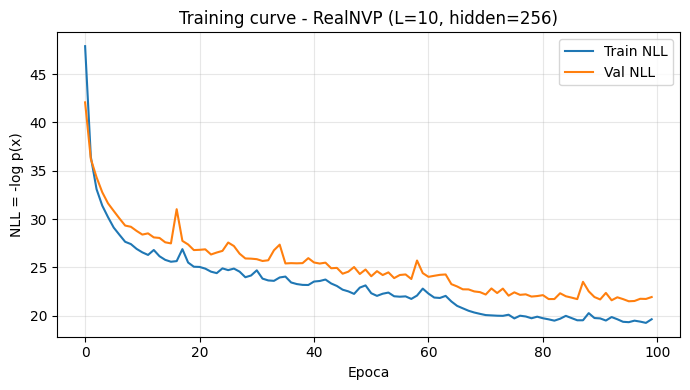

In [23]:
# ── Curva di training: NLL su train e validation lungo le epoche ─────────────
# Se le due curve scendono insieme e restano vicine, il modello impara senza overfitting.
fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(train_nlls, label='Train NLL')
ax.plot(val_nlls,   label='Val NLL')
ax.set_xlabel('Epoca'); ax.set_ylabel('NLL = -log p(x)')
ax.set_title(f'Training curve - RealNVP (L={N_LAYERS}, hidden={HIDDEN_UNITS})')
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(PLOTS_DIR, 'nf_training_curve.png'), dpi=130, bbox_inches='tight')
plt.show()


---
## 6. Anomaly score = NLL

> **In breve.** Per ogni jet misuriamo quanto il modello lo trova «improbabile»: più è improbabile, più è sospetto. Ci aspettiamo che gli Emerging Jets risultino più improbabili (score più alto) dei normali jet QCD.

Lo score di anomalia di un jet è la sua **NLL**, cioè `−log p(x)`. L'interpretazione è diretta: se
il flow assegna a un jet una probabilità bassa — cosa che impara a fare per i jet *diversi* da
quelli QCD su cui è stato allenato — quel jet ha una NLL alta ed è candidato anomalo. Ci aspettiamo
quindi che gli Emerging Jets mostrino, in media, una NLL più alta del fondo QCD.

In questa sezione usiamo per la **prima volta** i jet di test e il segnale: durante tutto
l'addestramento non sono mai stati toccati, quindi la valutazione è onesta. L'istogramma che
costruiamo è proprio il confronto fra la distribuzione di NLL dei jet normali (QCD) e di quelli
anomali (EJ).


In [24]:
def compute_nf_scores(model, X_np, batch_size=8192, device=DEVICE):
    '''Calcola lo score di anomalia per ogni jet: NLL = -log p(x).'''
    model.eval(); scores = []
    loader = DataLoader(TensorDataset(torch.from_numpy(X_np.astype(np.float32))),
                        batch_size=batch_size)
    with torch.no_grad():
        for (xb,) in loader:
            scores.append((-model.log_prob(xb.to(device))).cpu().numpy())
    return np.concatenate(scores)

# usiamo i dati standardizzati (la stessa trasformazione applicata in addestramento)
scores_bkg = compute_nf_scores(model, X_bkg_test_n)
scores_sig = compute_nf_scores(model, X_sig_n)

print(f'QCD (test) - NLL media: {scores_bkg.mean():.3f} +/- {scores_bkg.std():.3f}')
print(f'EJ         - NLL media: {scores_sig.mean():.3f} +/- {scores_sig.std():.3f}')
print(f'Delta (EJ - QCD): {scores_sig.mean() - scores_bkg.mean():+.3f}  (positivo = EJ piu anomalo)')


QCD (test) - NLL media: 21.856 +/- 32.036
EJ         - NLL media: 39.725 +/- 59.357
Delta (EJ - QCD): +17.869  (positivo = EJ piu anomalo)


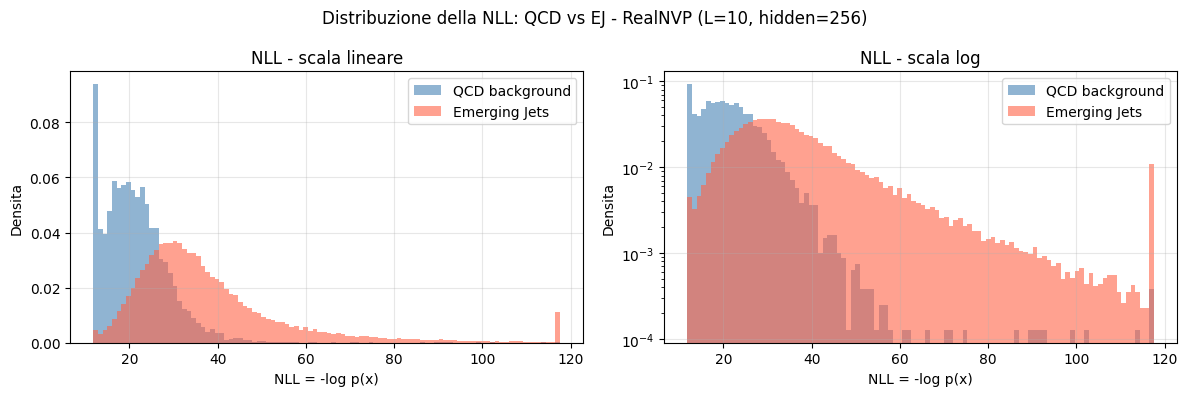

In [25]:
# ── Istogramma della NLL: jet normali (QCD) vs anomali (EJ) ──────────────────
# Per la sola visualizzazione tagliamo l'1% di code estreme, cosi' l'asse resta leggibile.
both = np.concatenate([scores_bkg, scores_sig])
lo, hi = np.percentile(both, 1), np.percentile(both, 99)
sb, ss = np.clip(scores_bkg, lo, hi), np.clip(scores_sig, lo, hi)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, logy in zip(axes, [False, True]):
    ax.hist(sb, bins=100, density=True, alpha=0.6, label='QCD background', color='steelblue')
    ax.hist(ss, bins=100, density=True, alpha=0.6, label='Emerging Jets',  color='tomato')
    ax.set_xlabel('NLL = -log p(x)'); ax.set_ylabel('Densita')
    ax.set_title('NLL - scala log' if logy else 'NLL - scala lineare')
    if logy: ax.set_yscale('log')
    ax.legend(); ax.grid(alpha=0.3)
plt.suptitle(f'Distribuzione della NLL: QCD vs EJ - RealNVP (L={N_LAYERS}, hidden={HIDDEN_UNITS})')
plt.tight_layout()
plt.savefig(os.path.join(PLOTS_DIR, 'nf_nll_distributions.png'), dpi=130, bbox_inches='tight')
plt.show()


---
## 7. Valutazione — ROC, AUC e SIC

> **In breve.** Controlliamo quanto bene lo score separa davvero i jet anomali da quelli normali, con i grafici e i numeri standard (ROC, AUC, SIC). Più l'AUC è vicina a 1, meglio è.

Misuriamo quanto bene lo score separa il segnale dal fondo con le metriche standard:

- **AUC**: la probabilità che un Emerging Jet, preso a caso, abbia score più alto di un jet QCD
  preso a caso (0.5 = scelta casuale, 1.0 = separazione perfetta).
- **SIC** (Significance Improvement Characteristic), `ε_S / √ε_B`: di quanto migliora la
  significatività statistica del segnale applicando un taglio sullo score, rispetto a non tagliare.

Sono le stesse metriche usate per AE e VAE, così il confronto fra i tre modelli è diretto.


VALUTAZIONE FINALE (test-QCD + segnale, mai visti in addestramento)
  Config : L=10, hidden=256, wd=1e-05
  AUC    : 0.8527
  N test-QCD: 7,500  |  N segnale: 61,966


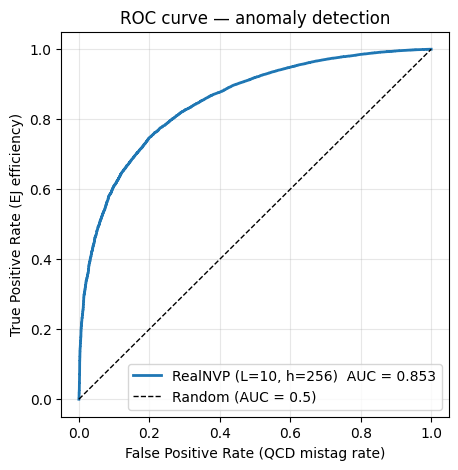

SIC massima : 2.551 @ eps_S = 0.20


In [26]:
fpr, tpr, roc_auc = compute_roc(scores_bkg, scores_sig)
print('=' * 55)
print('VALUTAZIONE FINALE (test-QCD + segnale, mai visti in addestramento)')
print('=' * 55)
print(f'  Config : L={N_LAYERS}, hidden={HIDDEN_UNITS}, wd={WEIGHT_DECAY}')
print(f'  AUC    : {roc_auc:.4f}')
print(f'  N test-QCD: {len(scores_bkg):,}  |  N segnale: {len(scores_sig):,}')

plot_roc(fpr, tpr, roc_auc,
         label=f'RealNVP (L={N_LAYERS}, h={HIDDEN_UNITS})',
         save_path=os.path.join(PLOTS_DIR, 'nf_roc_finale.png'))
plt.show()

# SIC: il picco indica il taglio sullo score che massimizza la significativita' del segnale
m   = fpr > 0
sic = tpr[m] / np.sqrt(fpr[m])
print(f'SIC massima : {sic.max():.3f} @ eps_S = {tpr[m][sic.argmax()]:.2f}')


---
## 8. Tuning degli iperparametri

> **In breve.** Proviamo diverse «taglie» del modello (più o meno strati e neuroni) e diversi livelli di regolarizzazione, per trovare la combinazione migliore — usando solo i jet QCD, mai il segnale.

Vogliamo capire quali scelte rendono il flow migliore. Per un normalizing flow le manopole sono:

- **Profondità** (`n_layers`) e **larghezza** (`hidden`): insieme determinano la *capacità* del
  modello. Aumentandole la NLL di validazione scende **in modo monotòno** (più capacità → modella
  sempre meglio il QCD). Per questo non scegliamo il valore con la NLL più bassa in assoluto, ma il
  **gomito** della curva (principio di Occam): un flow troppo flessibile rischia di assegnare alta
  densità *anche* al segnale, peggiorando la capacità di distinguerlo.
- **Regolarizzazione** (`weight_decay`): non è una capacità, quindi qui scegliamo semplicemente il
  valore con la **NLL di validazione minima**.

Il **criterio di selezione** è sempre la **NLL di validazione sul QCD**: misura quanto bene il flow
modella il fondo, senza mai usare il segnale. L'AUC, che richiederebbe il segnale, la guardiamo
solo alla fine come verifica, mai come criterio di scelta.


In [27]:
def train_flow_for_tuning(n_layers, hidden, weight_decay,
                          n_epochs=30, lr=1e-3, patience=7, device=DEVICE):
    '''Allena un flow (solo QCD) e restituisce la miglior NLL di validazione raggiunta.
       30 epoche bastano per confrontare RELATIVAMENTE le configurazioni; il segnale
       non viene mai toccato e non si calcola nessuna AUC.'''
    torch.manual_seed(SEED)
    m   = build_realnvp(INPUT_DIM, n_layers, hidden).to(device)
    opt = torch.optim.Adam(m.parameters(), lr=lr, weight_decay=weight_decay)
    sched = torch.optim.lr_scheduler.ReduceLROnPlateau(opt, patience=3, factor=0.5)
    best, wait = float('inf'), 0
    for _ in range(n_epochs):
        m.train()
        for (xb,) in train_loader:
            xb = xb.to(device)
            loss = -m.log_prob(xb).mean()
            opt.zero_grad(); loss.backward()
            torch.nn.utils.clip_grad_norm_(m.parameters(), GRAD_CLIP)
            opt.step()
        m.eval(); acc = 0.0
        with torch.no_grad():
            for (xb,) in val_loader:
                xb = xb.to(device)
                acc += (-m.log_prob(xb).mean()).item() * len(xb)
        val = acc / n_val
        sched.step(val)
        if val < best - 1e-4:
            best, wait = val, 0
        else:
            wait += 1
            if wait >= patience: break
    return best


In [28]:
# ━━━ Esperimento 1 - Profondità (n_layers) ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# La capacita' fa scendere la NLL in modo monotono: si sceglie il GOMITO, non il minimo.
print('Esperimento 1: profondita  (criterio: val NLL QCD)')
print(f"{'n_layers':>9} | {'val NLL':>12}")
print('-' * 26)
depth_results = {}
for L in [4, 6, 10, 16]:
    depth_results[L] = train_flow_for_tuning(L, HIDDEN_UNITS, WEIGHT_DECAY)
    print(f'{L:>9} | {depth_results[L]:>12.4f}')


Esperimento 1: profondita  (criterio: val NLL QCD)
 n_layers |      val NLL
--------------------------
        4 |      29.3723
        6 |      27.2288
       10 |      25.4996
       16 |      25.0497


In [29]:
# ━━━ Esperimento 2 - Larghezza (hidden) ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# Anche la larghezza e' capacita': di nuovo si guarda il GOMITO della curva.
print('Esperimento 2: larghezza  (criterio: val NLL QCD)')
print(f"{'hidden':>9} | {'val NLL':>12}")
print('-' * 26)
width_results = {}
for H in [64, 128, 256, 512]:
    width_results[H] = train_flow_for_tuning(N_LAYERS, H, WEIGHT_DECAY)
    print(f'{H:>9} | {width_results[H]:>12.4f}')


Esperimento 2: larghezza  (criterio: val NLL QCD)
   hidden |      val NLL
--------------------------
       64 |      27.9064
      128 |      26.1816
      256 |      25.4996
      512 |      26.1018


In [30]:
# ━━━ Esperimento 3 - Regolarizzazione (weight_decay) ━━━━━━━━━━━━━━━━━━━━━━━━━
# La regolarizzazione non e' capacita': qui il criterio e' direttamente la val NLL minima.
print('Esperimento 3: weight_decay  (criterio: val NLL QCD minima)')
print(f"{'weight_decay':>13} | {'val NLL':>12}")
print('-' * 30)
wd_results = {}
for wd in [0.0, 1e-5, 1e-4, 1e-3]:
    wd_results[wd] = train_flow_for_tuning(N_LAYERS, HIDDEN_UNITS, wd)
    print(f'{wd:>13.0e} | {wd_results[wd]:>12.4f}')
best_wd = min(wd_results, key=wd_results.get)
print(f'\nMiglior weight_decay (NLL minima): {best_wd:.0e}')


Esperimento 3: weight_decay  (criterio: val NLL QCD minima)
 weight_decay |      val NLL
------------------------------
        0e+00 |      26.0696
        1e-05 |      25.4996
        1e-04 |      25.5165
        1e-03 |      26.1316

Miglior weight_decay (NLL minima): 1e-05


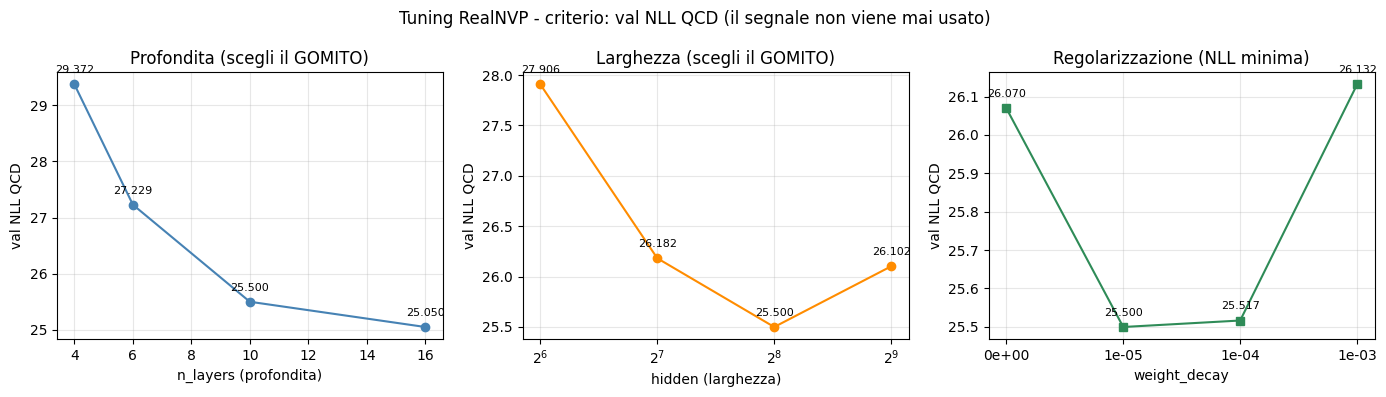

In [31]:
# ── Riepilogo del tuning: una curva per ciascuna manopola ────────────────────
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

ax = axes[0]
ks, vs = list(depth_results), list(depth_results.values())
ax.plot(ks, vs, 'o-', color='steelblue')
ax.set_xlabel('n_layers (profondita)'); ax.set_ylabel('val NLL QCD')
ax.set_title('Profondita (scegli il GOMITO)'); ax.grid(alpha=0.3)
for k, v in zip(ks, vs):
    ax.annotate(f'{v:.3f}', (k, v), textcoords='offset points', xytext=(0, 8), ha='center', fontsize=8)

ax = axes[1]
ks, vs = list(width_results), list(width_results.values())
ax.plot(ks, vs, 'o-', color='darkorange'); ax.set_xscale('log', base=2)
ax.set_xlabel('hidden (larghezza)'); ax.set_ylabel('val NLL QCD')
ax.set_title('Larghezza (scegli il GOMITO)'); ax.grid(alpha=0.3)
for k, v in zip(ks, vs):
    ax.annotate(f'{v:.3f}', (k, v), textcoords='offset points', xytext=(0, 8), ha='center', fontsize=8)

ax = axes[2]
labels = [f'{w:.0e}' for w in wd_results]; vs = list(wd_results.values()); xs = list(range(len(labels)))
ax.plot(xs, vs, 's-', color='seagreen')
ax.set_xticks(xs); ax.set_xticklabels(labels)
ax.set_xlabel('weight_decay'); ax.set_ylabel('val NLL QCD')
ax.set_title('Regolarizzazione (NLL minima)'); ax.grid(alpha=0.3)
for x, v in zip(xs, vs):
    ax.annotate(f'{v:.3f}', (x, v), textcoords='offset points', xytext=(0, 8), ha='center', fontsize=8)

plt.suptitle('Tuning RealNVP - criterio: val NLL QCD (il segnale non viene mai usato)')
plt.tight_layout()
plt.savefig(os.path.join(PLOTS_DIR, 'nf_tuning_summary.png'), dpi=130, bbox_inches='tight')
plt.show()
